# Module 03: EDA

In [1]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [2]:
# Load the data
Hitters = load_data('Hitters')

### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [3]:
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [4]:
for col in Hitters.columns:
    print(col, Hitters[col].dtype)
    

AtBat int64
Hits int64
HmRun int64
Runs int64
RBI int64
Walks int64
Years int64
CAtBat int64
CHits int64
CHmRun int64
CRuns int64
CRBI int64
CWalks int64
League category
Division category
PutOuts int64
Assists int64
Errors int64
Salary float64
NewLeague category


### Before doing any other analyses, let's create training and test sets.

In [5]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 

### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

The columns that start with 'C' stand for career stats

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

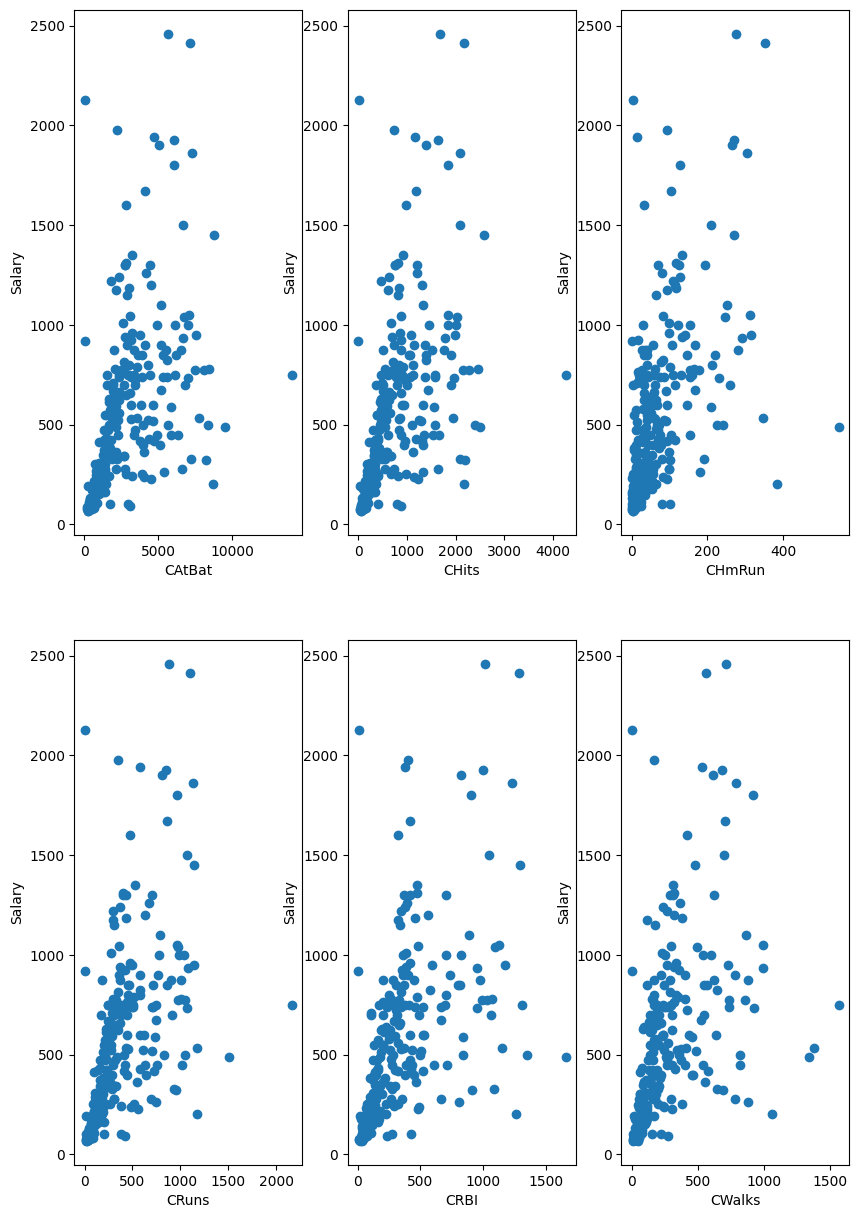

In [6]:
career_cols = [col for col in Hitters.columns if col.startswith('C')]

# Initialize the plots before drawing them
nrows = 2
ncols = 3
figsize = (5*nrows, 5*ncols)

fig, axes = subplots(nrows=nrows,
                     ncols=ncols,
                     figsize=figsize)

# Assign a grid location to each index
def range_to_grid(i, nrows, ncols):
    x=[]
    y=[]
    for n in range(nrows*ncols):
        x.append(n // ncols)
        y.append(n % ncols)
        # print(n,x[n],y[n]) # for testing this function
    return x[i],y[i]

# Plot the variables
for j in range(len(career_cols)):
    # print(range_to_grid(j,nrows,ncols)[0], range_to_grid(j,nrows,ncols)[1]) # testing
    row, col = range_to_grid(j, nrows, ncols)
    axes[row, col].plot(Hitters[career_cols[j]], Hitters['Salary'], 'o')
    axes[row, col].set_xlabel(career_cols[j])
    axes[row, col].set_ylabel("Salary")

### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [7]:
Hitters.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

array([[<Axes: title={'center': 'AtBat'}>]], dtype=object)

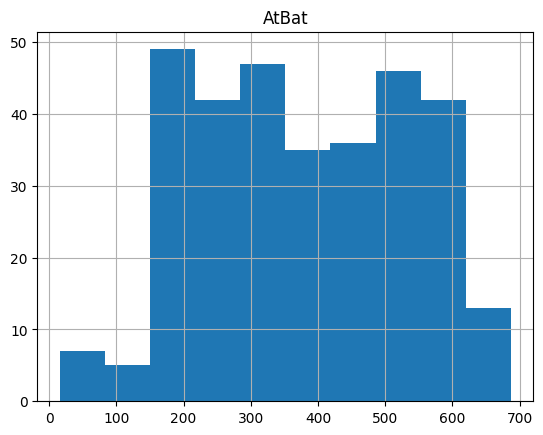

In [8]:
Hitters.hist(column='AtBat')

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [9]:
Train['AtBat_st'] = (Train['AtBat'] - Train['AtBat'].mean()) / Train['AtBat'].std()

### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [10]:
print(len(Train['AtBat']))

193


### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

The count of the 'Salary' column does not match the rest of the other variables, which are equal to 322. 'Salary''s value is 263, meaning there are 59 missing data entries (322-263=59)

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

If the variable contained values of 0, or a placeholder is used like 'NONE'

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

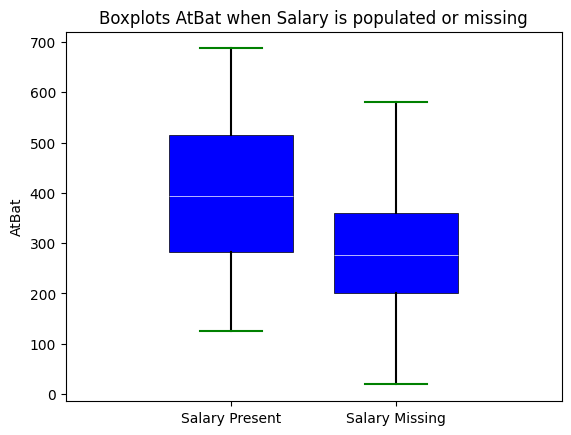

In [11]:
fig, ax = plt.subplots()

atbat_salary_present = Train.loc[Train['Salary'].notna(), 'AtBat']
atbat_salary_missing = Train.loc[Train['Salary'].isna(), 'AtBat']

ax.boxplot(
           [atbat_salary_present, atbat_salary_missing],
           positions=[2,4],
           widths=1.5,
           patch_artist=True,
           showmeans=False,
           showfliers=False,
           medianprops={"color": "white", "linewidth": 0.5},
           boxprops={"facecolor": "blue", "edgecolor": "black", "linewidth": 0.5},
           whiskerprops={"color": "black", "linewidth": 1.5}, 
           capprops={"color": "green", "linewidth": 1.5})

ax.set(xlim=(0, 6),
       xticks=[2,4],
       xticklabels=['Salary Present', 'Salary Missing'],
       ylabel='AtBat'
)
ax.set_title("Boxplots AtBat when Salary is populated or missing")

plt.show()

### Create a correlation matrix for all numeric features in the training set

In [12]:
Train.select_dtypes(include='number').corr()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,AtBat_st
AtBat,1.000000,0.963324,0.540323,0.906579,0.798717,0.631824,-0.039232,0.126602,0.146763,0.150166,0.164892,0.145779,0.056578,0.345879,0.363085,0.368162,0.401390,1.000000
Hits,0.963324,1.000000,0.516853,0.914739,0.795316,0.605876,-0.028717,0.133316,0.163329,0.136865,0.175542,0.153011,0.065178,0.312858,0.310422,0.301725,0.432558,0.963324
HmRun,0.540323,0.516853,1.000000,0.618439,0.840613,0.385425,0.009072,0.078981,0.076914,0.411917,0.110767,0.218285,0.080296,0.222084,-0.069088,0.062840,0.326021,0.540323
Runs,0.906579,0.914739,0.618439,1.000000,0.786635,0.711346,-0.069584,0.083770,0.103859,0.160979,0.159683,0.115628,0.099025,0.289952,0.184714,0.217297,0.441499,0.906579
RBI,0.798717,0.795316,0.840613,0.786635,1.000000,0.553527,0.046705,0.165837,0.180526,0.375072,0.191452,0.285074,0.117109,0.323825,0.138896,0.217983,0.414623,0.798717
Walks,0.631824,0.605876,0.385425,0.711346,0.553527,1.000000,0.037943,0.137157,0.147019,0.194766,0.205250,0.167453,0.312812,0.317000,0.139008,0.160753,0.458462,0.631824
Years,-0.039232,-0.028717,0.009072,-0.069584,0.046705,0.037943,1.000000,0.925308,0.906857,0.730478,0.882559,0.882835,0.836809,0.071301,-0.091915,-0.160476,0.541390,-0.039232
CAtBat,0.126602,0.133316,0.078981,0.083770,0.165837,0.137157,0.925308,1.000000,0.995185,0.775167,0.979705,0.948617,0.894573,0.120875,-0.000507,-0.068187,0.616677,0.126602
CHits,0.146763,0.163329,0.076914,0.103859,0.180526,0.147019,0.906857,0.995185,1.000000,0.761920,0.983128,0.945002,0.883547,0.132818,-0.003372,-0.062669,0.629875,0.146763
CHmRun,0.150166,0.136865,0.411917,0.160979,0.375072,0.194766,0.730478,0.775167,0.761920,1.000000,0.782490,0.912134,0.750795,0.126756,-0.129640,-0.141514,0.616170,0.150166


### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

Since the boxplot of mmissing values appears to be skewed right, median imputation would be appropriate since it is robust. Another strategy would be to look at how stats like hits, runs, and home runs appear to affect the salary. For example, the career stats show a positive correlation for a player's salary, showing a slightly above average score (above 0.6)

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

In [13]:
TotHits = Train['Hits'].sum()
TotWalks = Train['Walks'].sum()
TotAtBat = Train['AtBat'].sum()

Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat-TotHits-TotWalks]

print(TotHits)
print(TotWalks)
print(TotAtBat)

19599
7420
73693


26.60
10.07
63.34
['26.60', '10.07', '63.34']


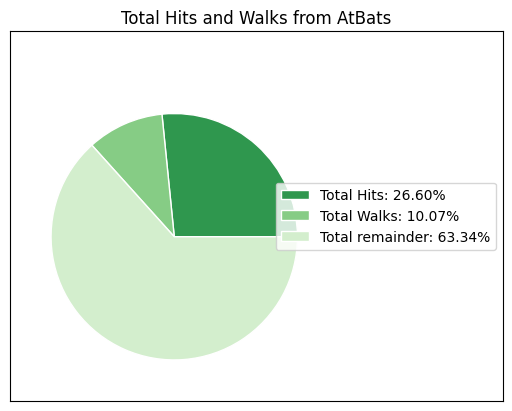

In [33]:
total_hits = Train['Hits'].sum()
total_walks = Train['Walks'].sum()
total_at_bats = Train['AtBat'].sum()
total_remainder = total_at_bats - total_hits - total_walks

totals = [total_hits, total_walks, total_remainder]

percent_labels = []
percent_values = []

for total in totals:
    stat_percent = (total / total_at_bats) * 100
    percent_values.append(stat_percent)
    percent_labels.append("{:.2f}".format(stat_percent))
    print("{:.2f}".format(stat_percent))

print(percent_labels)

types = [f"Total Hits: {percent_labels[0]}%", f"Total Walks: {percent_labels[1]}%", f"Total remainder: {percent_labels[2]}%"]

# Define a range of colors
colors = plt.get_cmap('Greens')(np.linspace(0.7, 0.2, len(percent_labels)))

# Create a figure and axes
fig, ax = plt.subplots()

# Create the pie chart
ax.pie(percent_values, colors=colors, radius=3, center=(4, 4),
       wedgeprops={"linewidth": 1, "edgecolor": "white"}, frame=True)

# Include a legend
ax.legend(types, loc="right")

# Adjust the axes
ax.set(xlim=(0, 12), xticks=np.arange(1, 8),
       ylim=(0, 9), yticks=np.arange(1, 8))
ax.tick_params(left = False, labelleft = False, 
               bottom = False, labelbottom = False)
ax.set(title="Total Hits and Walks from AtBats")

plt.show()


### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [35]:

Train['AVG'] = (Train['Hits'] / Train['AtBat']) * 100

### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [38]:
Train['AVG_bin'] = 'medium'
Train['AVG_bin'][Train['AVG'] < 0.25] = 'low'
Train['AVG_bin'][Train['AVG'] >= 0.31] = 'high'

C:\Users\cdrSp\AppData\Local\Temp\ipykernel_16652\3699071697.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  Train['AVG_bin'][Train['AVG'] < 0.25] = 'low'
C:\Users\cdrSp\AppData\Local\Temp\ipykernel_16652\3699071697.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behav

### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

In [39]:
Train['AVG_bin'].value_counts()

AVG_bin
medium    193
Name: count, dtype: int64

Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [44]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts().get(i, 0) for i in indexMap]

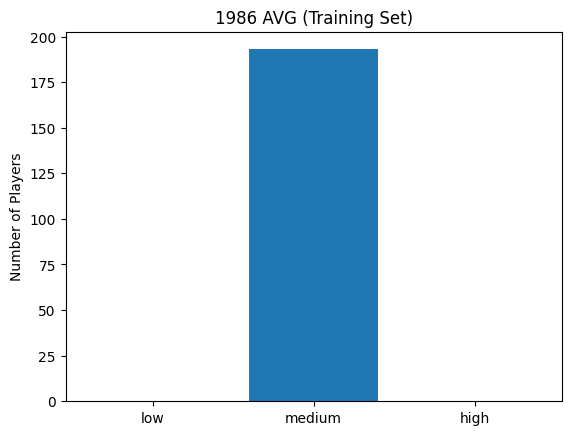

In [45]:
plt.bar([0, 1, 2], reordered_list)

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks([0, 1, 2], ['low', 'medium', 'high'])

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

Equal width binning because it uses 0.25 and 0.31 as split points, so it doesn't matter how many players fall into each range. Since all of the data ends up in the medium bin, there is no room for data to be equally distributed to the low and high bins.